# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [6]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [7]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


In [8]:
# Task 1
# YOUR CODE HERE
# Task 1 — Histogram: Price Distribution by Room Type

# Filter required room types
hist_df = df_cap[
    df_cap['room_type'].isin(['Entire home/apt', 'Private room'])
]

# Median prices
entire_median = hist_df[
    hist_df['room_type'] == 'Entire home/apt'
]['price'].median()

private_median = hist_df[
    hist_df['room_type'] == 'Private room'
]['price'].median()

# Create histogram
fig = px.histogram(
    hist_df,
    x='price',
    color='room_type',
    barmode='overlay',
    opacity=0.6,
    nbins=50,
    template='simple_white',
    color_discrete_map={
        'Entire home/apt': 'crimson',
        'Private room': 'steelblue'
    }
)

# Median lines
fig.add_vline(
    x=entire_median,
    line_color='crimson',
    line_width=3,
    line_dash='dash'
)

fig.add_vline(
    x=private_median,
    line_color='steelblue',
    line_width=3,
    line_dash='dash'
)

# Layout styling
fig.update_layout(
    title='Entire homes are generally far more expensive than private rooms',
    font=dict(family='Arial', size=12),
    width=1000,
    height=600
)

# Clean styling
fig.update_xaxes(
    title='Price',
    showgrid=False
)

fig.update_yaxes(
    title='Count',
    gridcolor='#EEEEEE'
)

fig.show()

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

/var/folders/cc/vr511rw96dlflmw7t8jb3qym0000gn/T/ipykernel_9669/3624429880.py:27: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



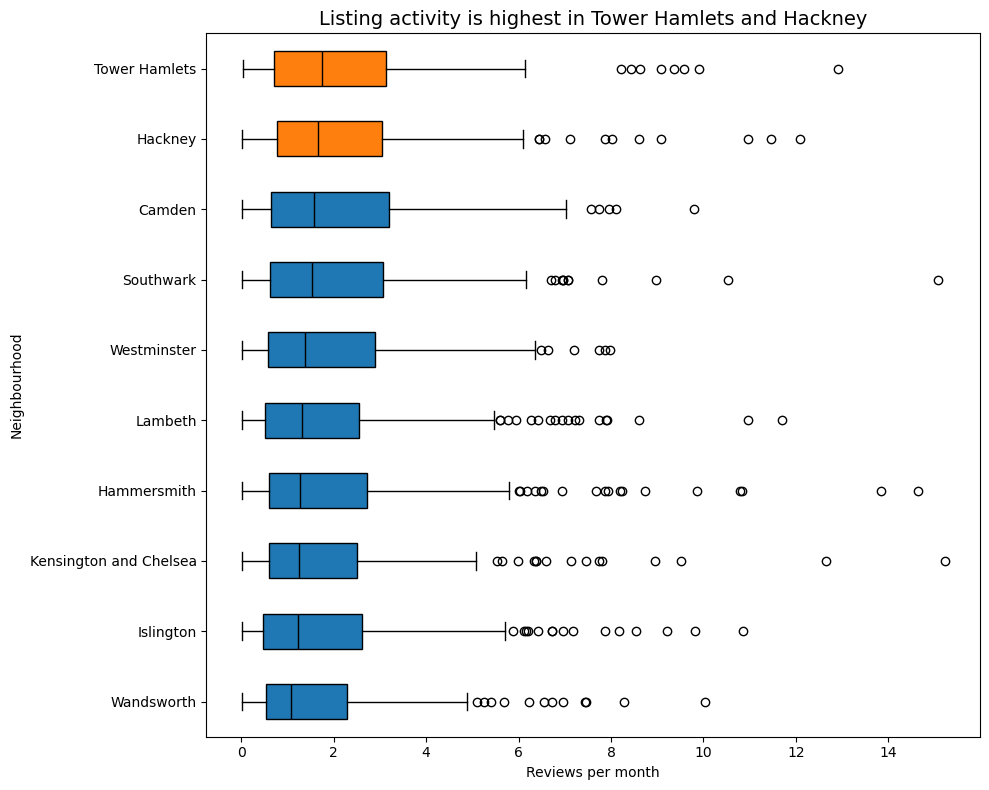

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Filter out inactive listings ---
df_plot = df[df["reviews_per_month"] > 0].copy()

# --- 2. Compute ordering by median activity ---
neighbourhood_order = (
    df_plot.groupby("neighbourhood")["reviews_per_month"]
    .median()
    .sort_values(ascending=False)
    .index
)

# --- 3. Prepare data for boxplot ---
data = [
    df_plot[df_plot["neighbourhood"] == n]["reviews_per_month"].values
    for n in neighbourhood_order
]

# --- 4. Top 2 most active neighbourhoods ---
top2 = set(neighbourhood_order[:2])

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(10, 8))

bp = ax.boxplot(
    data,
    vert=False,
    labels=neighbourhood_order,
    patch_artist=True,
    showfliers=True
)

# --- 6. Color styling ---
for patch, n in zip(bp["boxes"], neighbourhood_order):
    patch.set_facecolor("#ff7f0e" if n in top2 else "#1f77b4")

for median in bp["medians"]:
    median.set_color("black")

# --- 7. Order: most active at top ---
ax.invert_yaxis()

# --- 8. Insight title ---
top2_list = list(neighbourhood_order[:2])
ax.set_title(
    f"Listing activity is highest in {top2_list[0]} and {top2_list[1]}",
    fontsize=14
)

ax.set_xlabel("Reviews per month")
ax.set_ylabel("Neighbourhood")

plt.tight_layout()
plt.show()

In [10]:
print(df.columns)

Index(['neighbourhood', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'availability_365', 'reviews_per_month'],
      dtype='object')
